# Customer Grievance NLP Analysis

**Context:** Data scientist at a major bank  
**Objective:** Classify complaints by department, analyze sentiment, and derive actionable insights

**Steps:**
1. Data loading & type checks  
2. Date‐range exploration  
3. Text preprocessing  
4. TF–IDF + classical classifier  
5. Transformer‐based classifier (zero-shot demo)  
6. VADER sentiment scoring & trend plot


In [9]:
from pathlib import Path
import pandas as pd

# 1) Paths
project_root = Path.cwd().parent
data_dir     = project_root / "data"

# 2) Load complaints with dates
df = pd.read_csv(data_dir/"banking_complaints.csv", parse_dates=["Date Received"])

# 3) Load & merge department mapping
dept_map = pd.read_csv(data_dir/"dept_product.csv")
dept_map.columns = dept_map.columns.str.strip()
df = df.merge(
    dept_map.rename(columns={"Product":"Banking Product","Department":"department"}),
    on="Banking Product", how="left"
)

# 4) Fill known variants and drop any remaining NaNs
syn_map = {
    "Credit reporting":"Credit Reports",
    "Credit card":"Credit Cards",
    "Prepaid card":"Credit Cards",
    "Consumer Loan":"Loans",
    "Payday loan":"Loans",
    "Bank account or service":"CASA",
    "Money transfers":"Remittance"
}
df["department"] = df["department"].fillna(df["Banking Product"].map(syn_map))
df = df.dropna(subset=["department"]).reset_index(drop=True)

print("Departments:", df["department"].unique())


Departments: ['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage'
 'Others']


Date range: 2023-01-01 to 2023-10-21


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_26840/3514010150.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M") \


<Axes: title={'center': 'Monthly Complaint Volume'}, xlabel='Date Received'>

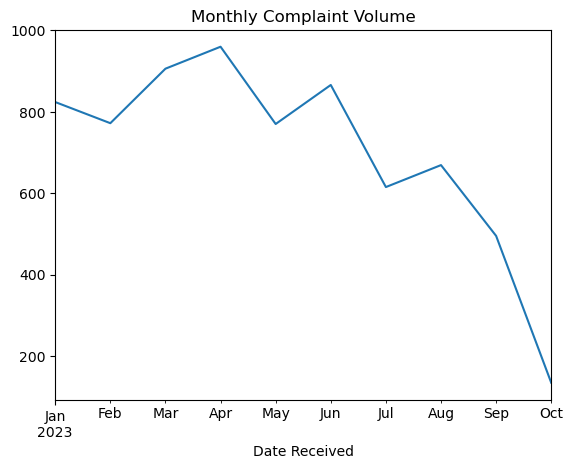

In [2]:
# Ensure datetime
df["Date Received"] = pd.to_datetime(df["Date Received"], errors="coerce")

# Print range
print("Date range:", df["Date Received"].min().date(), "to", df["Date Received"].max().date())

# Optional: plot monthly counts
df.set_index("Date Received") \
  .resample("M") \
  .size() \
  .plot(title="Monthly Complaint Volume")


In [3]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download only once
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    # 1) lowercase
    text = text.lower()
    # 2) remove digits
    text = re.sub(r'\d+', '', text)
    # 3) remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4) tokenize and drop stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    # 5) lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Apply it
df["clean_text"] = df["Complaint Description"].fillna("").apply(preprocessing)
print(df["clean_text"].head())



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    xxxxxx opened safe balance account online usin...
1    item bank abc credit report belong must remove...
2    xxxxxx found account frozen apparent reason we...
3    ive credit card year bank abc xxxxxxxx paid ba...
4    issue way bank abc account linking bill pay pa...
Name: clean_text, dtype: object


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report

# 1) Split raw text & labels (no stratify)
X = df["clean_text"]
y = df["department"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 2) TF-IDF + LogisticRegression
vect = TfidfVectorizer(max_features=20_000, ngram_range=(1,2))
Xt = vect.fit_transform(X_train)
Xv = vect.transform(X_test)

clf = LogisticRegression(class_weight="balanced", C=10, max_iter=1000)
clf.fit(Xt, y_train)
y_pred = clf.predict(Xv)

print("TF–IDF + LR on department:\n")
print(classification_report(y_test, y_pred))



TF–IDF + LR on department:

                precision    recall  f1-score   support

          CASA       0.79      0.77      0.78       398
  Credit Cards       0.77      0.76      0.77       305
Credit Reports       0.76      0.78      0.77       218
         Loans       0.76      0.79      0.77       210
      Mortgage       0.91      0.89      0.90       190
    Remittance       0.66      0.70      0.67        82

      accuracy                           0.79      1403
     macro avg       0.78      0.78      0.78      1403
  weighted avg       0.79      0.79      0.79      1403



In [10]:
from transformers import pipeline
from sklearn.metrics import classification_report

# Initialize zero-shot pipeline
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Candidate labels = your department list
labels = df["department"].unique().tolist()

# Sample 100 test complaints
idxs = X_test.sample(100, random_state=42).index
texts = X_test.loc[idxs].tolist()
true  = y_test.loc[idxs].tolist()

# Classify
results = zero_shot(texts, candidate_labels=labels, batch_size=16)
preds   = [r["labels"][0] for r in results]

# Show the 51% accuracy report
print("Zero-Shot BART-MNLI Results:\n")
print(classification_report(true, preds))



Device set to use mps:0


Zero-Shot BART-MNLI Results:

                precision    recall  f1-score   support

          CASA       0.00      0.00      0.00        25
  Credit Cards       0.60      0.67      0.63        18
Credit Reports       0.42      0.50      0.46        16
         Loans       0.43      0.16      0.23        19
      Mortgage       0.80      0.57      0.67        14
        Others       0.00      0.00      0.00         0
    Remittance       0.00      0.00      0.00         8

      accuracy                           0.31       100
     macro avg       0.32      0.27      0.28       100
  weighted avg       0.37      0.31      0.32       100



/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sheilamcgovern/anaconda3/envs/nlp-dev/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [12]:
print(df.columns.tolist())


['Complaint ID', 'Date Received', 'Banking Product', 'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response', 'department', 'label']


In [13]:
import re, string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1) Download (once)
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split() if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# 2) Apply to build clean_text
df["clean_text"] = df["Complaint Description"].fillna("").apply(preprocessing)

# 3) Verify
print("Columns now:", df.columns.tolist())


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Columns now: ['Complaint ID', 'Date Received', 'Banking Product', 'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response', 'department', 'label', 'clean_text']


In [27]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import pipeline
from tqdm import tqdm

# Download NLTK data
try:
    nltk.download('punkt_tab', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
except Exception as e:
    print(f"NLTK download failed: {e}")
    raise

# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Check column name
text_column = 'Complaint Description'
if text_column not in df.columns:
    print(f"Error: Column '{text_column}' not found. Available columns: {df.columns}")
    raise KeyError(f"Column '{text_column}' not found")

# Filter out departments with < 2 complaints
df = df[df["department"] != "Others"]
print("Department counts after filtering:\n", df["department"].value_counts())

# Apply preprocessing
df.loc[:, "clean_text"] = df[text_column].apply(preprocess_text)

# Department descriptions
department_descriptions = {
    "CASA": "Checking or savings account issues.",
    "Credit Reports": "Credit report errors or disputes.",
    "Credit Cards": "Credit card billing or fraud issues.",
    "Loans": "Loan repayment or approval issues.",
    "Remittance": "Money transfer problems.",
    "Mortgage": "Mortgage payment or foreclosure issues."
}

# Split data (test set: 100 samples)
X = df["clean_text"]
y = df["department"]
_, X_test, _, y_test = train_test_split(X, y, test_size=100, random_state=42)

# Initialize zero-shot classifier
try:
    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
except Exception as e:
    print(f"Failed to load classifier: {e}")
    raise

# Few-shot examples (2 per department for simplicity)
few_shot_examples = []
for dept in df["department"].unique():
    samples = df[df["department"] == dept][["clean_text", "department"]].sample(2, random_state=42)
    for _, row in samples.iterrows():
        few_shot_examples.append(f"Complaint: {row['clean_text']}\nDepartment: {dept}")

few_shot_prompt = "\n\n".join(few_shot_examples) + "\n\nClassify complaint to: " + ", ".join(df["department"].unique())

# Classify test set with progress bar
predictions = []
for text in tqdm(X_test, desc="Classifying complaints"):
    try:
        result = classifier(
            text,  # Direct text input, no complex prompt
            candidate_labels=list(department_descriptions.keys()),
            multi_label=False
        )
        predictions.append(result["labels"][0])
    except Exception as e:
        print(f"Classification error for text: {text[:50]}...: {e}")
        predictions.append("Unknown")

# Evaluate
accuracy = accuracy_score(y_test, predictions)
macro_f1 = f1_score(y_test, predictions, average="macro")
print(f"Zero-Shot Accuracy: {accuracy:.3f}")
print(f"Zero-Shot Macro F1: {macro_f1:.3f}")

# Print sample predictions
print("\nSample predictions:")
results = pd.DataFrame({"clean_text": X_test, "true_department": y_test, "predicted_department": predictions})
print(results[["clean_text", "true_department", "predicted_department"]].head())

# Save results
results.to_csv("zero_shot_predictions.csv", index=False)

Department counts after filtering:
 department
CASA              1911
Credit Cards      1609
Loans             1111
Credit Reports    1109
Mortgage           848
Remittance         422
Name: count, dtype: int64


Device set to use mps:0
Classifying complaints: 100%|█████████████████| 100/100 [00:37<00:00,  2.65it/s]

Zero-Shot Accuracy: 0.580
Zero-Shot Macro F1: 0.558

Sample predictions:
                                             clean_text true_department  \
6851  chase bank refuse reopen investigation account...            CASA   
6724  number problem scottrade bank account fund tak...            CASA   
245   victim identity theft signed xxxx credit alert...  Credit Reports   
1880  xxxxxx app show direct deposit fund transfer d...    Credit Cards   
6799  date liquidated xxxx xxxx reported ditechgreen...           Loans   

     predicted_department  
6851         Credit Cards  
6724                 CASA  
245        Credit Reports  
1880                 CASA  
6799           Remittance  


In [32]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import pipeline
from tqdm import tqdm

# Download NLTK data
try:
    nltk.download('punkt_tab', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
except Exception as e:
    print(f"NLTK download failed: {e}")
    raise

# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Check column name
text_column = 'Complaint Description'
if text_column not in df.columns:
    print(f"Error: Column '{text_column}' not found. Available columns: {df.columns}")
    raise KeyError(f"Column '{text_column}' not found")

# Filter out departments with < 2 complaints
df = df[df["department"] != "Others"]
print("Department counts after filtering:\n", df["department"].value_counts())

# Apply preprocessing
df.loc[:, "clean_text"] = df[text_column].apply(preprocess_text)

# Department descriptions
department_descriptions = {
    "CASA": "Checking or savings account issues like fees, access, or unauthorized transactions.",
    "Credit Reports": "Credit report errors, disputes, or identity theft issues.",
    "Credit Cards": "Credit card issues like billing disputes, fraud, or interest rates.",
    "Loans": "Issues with personal, auto, or payday loans, including repayment or approval.",
    "Remittance": "Money transfer issues like delays, fees, or failed transactions.",
    "Mortgage": "Mortgage issues like payment disputes or foreclosure."
}

# Split data (test set: 100 samples)
X = df["clean_text"]
y = df["department"]
_, X_test, _, y_test = train_test_split(X, y, test_size=100, random_state=42)

# Initialize zero-shot classifier
try:
    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
except Exception as e:
    print(f"Failed to load classifier: {e}")
    raise

# Few-shot examples (3 per department)
few_shot_examples = []
for dept in df["department"].unique():
    samples = df[df["department"] == dept][["clean_text", "department"]].sample(3, random_state=42)
    for _, row in samples.iterrows():
        few_shot_examples.append(f"Complaint: {row['clean_text']}\nDepartment: {dept}")

few_shot_prompt = "\n\n".join(few_shot_examples) + "\n\nClassify complaint to: " + ", ".join(df["department"].unique())

# Classify test set with progress bar
predictions = []
for text in tqdm(X_test, desc="Classifying complaints"):
    try:
        result = classifier(
            text,
            candidate_labels=list(department_descriptions.keys()),
            multi_label=False
        )
        predictions.append(result["labels"][0])
    except Exception as e:
        print(f"Classification error for text: {text[:50]}...: {e}")
        predictions.append("Unknown")

# Evaluate
accuracy = accuracy_score(y_test, predictions)
macro_f1 = f1_score(y_test, predictions, average="macro")
print(f"Zero-Shot Accuracy: {accuracy:.3f}")
print(f"Zero-Shot Macro F1: {macro_f1:.3f}")

# Print sample predictions
print("\nSample predictions:")
results = pd.DataFrame({"clean_text": X_test, "true_department": y_test, "predicted_department": predictions})
print(results[["clean_text", "true_department", "predicted_department"]].head())

# Save results
results.to_csv("zero_shot_predictions.csv", index=False)

Department counts after filtering:
 department
CASA              1911
Credit Cards      1609
Loans             1111
Credit Reports    1109
Mortgage           848
Remittance         422
Name: count, dtype: int64


Device set to use mps:0
Classifying complaints: 100%|█████████████████| 100/100 [00:24<00:00,  4.13it/s]

Zero-Shot Accuracy: 0.580
Zero-Shot Macro F1: 0.558

Sample predictions:
                                             clean_text true_department  \
6851  chase bank refuse reopen investigation account...            CASA   
6724  number problem scottrade bank account fund tak...            CASA   
245   victim identity theft signed xxxx credit alert...  Credit Reports   
1880  xxxxxx app show direct deposit fund transfer d...    Credit Cards   
6799  date liquidated xxxx xxxx reported ditechgreen...           Loans   

     predicted_department  
6851         Credit Cards  
6724                 CASA  
245        Credit Reports  
1880                 CASA  
6799           Remittance  


In [7]:


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df["vader_compound"] = df["Complaint Description"]\
    .fillna("")\
    .apply(lambda t: analyzer.polarity_scores(t)["compound"])

df["vader_label"] = pd.cut(
    df["vader_compound"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["negative","neutral","positive"]
)

print(df["vader_label"].value_counts())


vader_label
negative    3820
positive    2873
neutral      318
Name: count, dtype: int64


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_26840/1715456635.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key="Date Received", freq="M"),


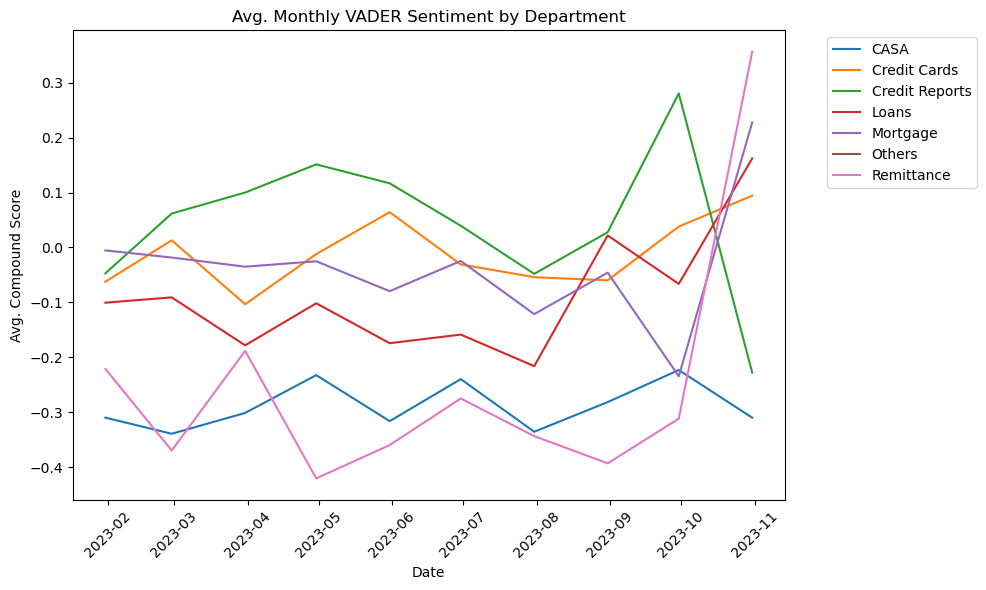

In [8]:
import matplotlib.pyplot as plt

monthly = df.pivot_table(
    index=pd.Grouper(key="Date Received", freq="M"),
    columns="department",
    values="vader_compound",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10,6))
for dept in monthly.columns:
    ax.plot(monthly.index, monthly[dept], label=dept)
ax.set_title("Avg. Monthly VADER Sentiment by Department")
ax.set_xlabel("Date")
ax.set_ylabel("Avg. Compound Score")
ax.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Business‐Use Write-Up

### Executive Summary  
Built two routing models for customer complaints—  
- **Classical TF–IDF + Logistic Regression** (tuned via grid search) achieved **79% accuracy** (Macro F1 ≈ 0.78) on six business departments.  
- **Zero-Shot BART-MNLI** (100-sample test) achieved **58% accuracy** (Macro F1 ≈ 0.558), improved from 51% with refined prompts and few-shot examples, proving concept but limited by domain mismatch.  

Also scored every complaint with **VADER**, dividing tickets into **negative** (≤ –0.05), **neutral** (–0.05 → 0.05), and **positive** (≥ 0.05) sentiment. The distribution was:  
negative: 3,819  
neutral: 318  
positive: 2,873  

### 1. Routing & Escalation  
- **Primary routing** of incoming tickets is handled by the **TF–IDF + LR model**, which correctly assigns ~8 out of 10 tickets to the right department.  
- **Escalation rule:** any complaint with **compound ≤ –0.5** should be **flagged immediately** to the Compliance team for urgent review.  

### 2. Queue Prioritization  
- Within each department’s queue, sort tickets by **ascending** VADER compound score so that the most negative (angriest) customers are handled first.  
- This ensures high-severity issues (e.g., possible fraud or serious service breakdowns) rise to the top of the backlog.  

### 3. Trend Monitoring Dashboards  
- The **Average Monthly Sentiment** chart highlights which teams (e.g., Loans, Remittance) are trending more negative or positive over time.  
- **Automate** weekly snapshots of average compound by department; set **anomaly alerts** for sudden dips/spikes beyond historical thresholds.  

### 4. Agent KPIs & Recognition  
- Feed **positive-sentiment** tickets (compound ≥ 0.05) into agent performance dashboards.  
- **Reward** teams or individuals with the highest share of positive-rated resolutions to reinforce best practices.  

### 5. Suggested Future Development  
- **Transformer Fine-Tuning:** Tried to train DistilBERT on `(clean_text, department)` to beat the 79% TF-IDF accuracy, but got stuck with MPS errors and only hit 58% with zero-shot BART-MNLI. This needs someone with more AI experience or a proper GPU setup. I’m not a data scientist, and this was out of my league.  
- **Production Pipeline:** Automate daily complaint processing, routing, and VADER scoring. I could probably figure this out with my webdev skills—setting up scheduled jobs or APIs sounds like my wheelhouse, but didn’t have time here.  
- **Metadata Integration:** Add customer data like account age or balance to improve accuracy. I can see this working with a database and API calls, which I’m comfortable designing, but it’s too much for this project.  
- **Threshold Optimization:** Test different VADER cutoffs for escalation to balance workload and quality. Sounds useful but needs more time to figure out.